<a href="https://colab.research.google.com/github/Larapraneeth/AI_DOCUMENT_ANALYZER/blob/main/AIDMINI_SO2_Comparison_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIDMINI — Rotation-Robustness Comparison
## D8 Group-Equivariant CNN  vs  SO(2) Steerable CNN

This notebook **extends** the existing D8 experiment. The D8 G-CNN checkpoint is
loaded from your Drive (not retrained). The **new SO(2) Steerable CNN is trained
in this notebook**, under the exact same config as D8, then a full scientific
comparison is run between the two.

| | D8 G-CNN | SO(2) Steerable CNN |
|---|---|---|
| Library | e2cnn | **escnn** |
| Symmetry | 8 rotations + 8 reflections (16 elements) | Continuous rotation, band-limited |
| Trained here? | No — loaded from checkpoint | **Yes** |

**Fair-comparison contract:** image size, split, optimizer, scheduler, LR, batch
size, and epoch count below are copied *exactly* from the D8 notebook.


## 1. Mount Google Drive

In [3]:
!pip uninstall -y numpy pandas
!pip install numpy==1.26.4 pandas==2.2.2 --no-cache-dir

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 262.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 176.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


## 2. Install Dependencies

We need **both** `e2cnn` (to reconstruct the D8 model class so its checkpoint can
be loaded) and `escnn` (for the new continuous SO(2) model). `escnn` is the
actively maintained successor to `e2cnn`; they can coexist.

In [2]:
!pip install e2cnn -q
!pip install escnn==1.0.11 -q
!pip install numpy==1.26.4 -q
print('e2cnn + escnn installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.3/225.3 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.9/373.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 8.5 MB/s eta 0:00:00
e2cnn + escnn installed.


In [3]:
!pip install --force-reinstall --no-deps pandas -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 101.9 MB/s eta 0:00:00


## 3. Imports

In [4]:
import os
import copy
import time
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Dataset

from PIL import Image
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support, balanced_accuracy_score,
                              roc_curve, auc, precision_recall_curve)
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# e2cnn (for reconstructing the D8 model)
from e2cnn import gspaces as e2_gspaces
from e2cnn import nn as e2nn

# escnn (for the new SO(2) model)
import escnn
from escnn import gspaces as esc_gspaces
from escnn import nn as enn

torch.manual_seed(42)
np.random.seed(42)

print(f'PyTorch     : {torch.__version__}')
print(f'Torchvision : {torchvision.__version__}')
print(f'CUDA        : {torch.cuda.is_available()}')

PyTorch     : 2.11.0+cu128
Torchvision : 0.26.0+cu128
CUDA        : True


## 4. Configuration

**Identical to the D8 notebook** — same image size, split, optimizer settings,
batch size and epoch budget, so the SO(2) model is trained under the same
conditions as D8.

Update the D8 checkpoint path below to match where your existing D8 `.pth` file
lives in Drive.

In [5]:
# ── Dataset paths ──────────────────────────────────────────────────────────
DATA_DIR = '/content/drive/MyDrive/AIDMINI'

# ── Existing D8 checkpoint (already trained — loaded, NOT retrained) ──────
D8_CKPT_PATH  = '/content/drive/MyDrive/gcnn_aidmini_best128.pth'     # <- from the D8 notebook (Cell 40)

# ── New SO(2) checkpoint (trained in this notebook) ───────────────────────
SO2_SAVE_PATH = '/content/drive/MyDrive/so2_aidmini_best128.pth'

# ── Output directories ──────────────────────────────────────────────────
OUT_ROOT = '/content/drive/MyDrive/AIDMINI_SO2_Comparison'
DIRS = {
    'plots':              f'{OUT_ROOT}/plots',
    'tables':             f'{OUT_ROOT}/tables',
    'confusion_matrices': f'{OUT_ROOT}/confusion_matrices',
    'checkpoints':        f'{OUT_ROOT}/checkpoints',
    'results':            f'{OUT_ROOT}/results',
}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

# ── Data (identical to D8 notebook) ───────────────────────────────────────
IMG_SIZE    = 128
BATCH_SIZE  = 16
VAL_SPLIT   = 0.2
NUM_WORKERS = 2

# ── Training (identical to D8 notebook) ───────────────────────────────────
NUM_EPOCHS    = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
STEP_SIZE     = 10
GAMMA         = 0.5

# ── Normalisation (identical to D8 notebook) ──────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'IMG_SIZE: {IMG_SIZE}  BATCH: {BATCH_SIZE}  EPOCHS: {NUM_EPOCHS}')

Device  : cuda
IMG_SIZE: 128  BATCH: 16  EPOCHS: 30


## 5. Data Loading & Split

Same seed (`42`) and same 80/20 split logic as the D8 notebook, so the val set
used for comparison here is the same set of images.

In [6]:
base_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

full_dataset = ImageFolder(root=DATA_DIR, transform=base_transforms)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Total images : {len(full_dataset)}')

val_size   = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_ds, val_ds = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {train_size} | Val: {val_size}')

Classes (20): ['Airport', 'BareLand', 'BaseballField', 'Beach', 'Bridge', 'Center', 'Church', 'Commercial', 'DenseResidential', 'Desert', 'Forest', 'Industrial', 'Meadow', 'MediumResidential', 'Mountain', 'Park', 'Parking', 'Playground', 'RailwayStation', 'River']
Total images : 1000
Train: 800 | Val: 200


In [7]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.95, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset_aug = ImageFolder(root=DATA_DIR, transform=train_transforms)
train_ds_aug = torch.utils.data.Subset(train_dataset_aug, train_ds.indices)

train_loader = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
print('Train loader rebuilt with augmentation.')

Train loader rebuilt with augmentation.


## 6. Model Definitions

Two classes:
1. `GCNN_D8` — copied unmodified from the D8 notebook. Used only to **load**
   the existing checkpoint.
2. `SO2SteerableCNN` — **new model**, built with `escnn` using a continuous
   rotation group `rot2dOnR2(N=-1)`. Equivariant to *any* rotation angle, not
   just multiples of 45°.


In [8]:
class GCNN_D8(nn.Module):
    """Group-Equivariant CNN using the Dihedral group D8 (copied from the
    existing D8 notebook, unmodified, so its checkpoint loads correctly)."""

    def __init__(self, num_classes, dropout=0.5):
        super().__init__()
        self.r2_act = e2_gspaces.FlipRot2dOnR2(N=8)

        in_type = e2nn.FieldType(self.r2_act, 3 * [self.r2_act.trivial_repr])
        self.input_type = in_type

        feat24  = e2nn.FieldType(self.r2_act, 24  * [self.r2_act.regular_repr])
        feat48  = e2nn.FieldType(self.r2_act, 48  * [self.r2_act.regular_repr])
        feat96  = e2nn.FieldType(self.r2_act, 96  * [self.r2_act.regular_repr])
        feat192 = e2nn.FieldType(self.r2_act, 192 * [self.r2_act.regular_repr])

        self.features = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, feat24, kernel_size=3, padding=1, bias=False),
            e2nn.InnerBatchNorm(feat24),
            e2nn.ReLU(feat24, inplace=True),
            e2nn.PointwiseMaxPool(feat24, kernel_size=2, stride=2),

            e2nn.R2Conv(feat24, feat48, kernel_size=3, padding=1, bias=False),
            e2nn.InnerBatchNorm(feat48),
            e2nn.ReLU(feat48, inplace=True),
            e2nn.PointwiseMaxPool(feat48, kernel_size=2, stride=2),

            e2nn.R2Conv(feat48, feat96, kernel_size=3, padding=1, bias=False),
            e2nn.InnerBatchNorm(feat96),
            e2nn.ReLU(feat96, inplace=True),
            e2nn.PointwiseMaxPool(feat96, kernel_size=2, stride=2),

            e2nn.R2Conv(feat96, feat192, kernel_size=3, padding=1, bias=False),
            e2nn.InnerBatchNorm(feat192),
            e2nn.ReLU(feat192, inplace=True),
            e2nn.PointwiseMaxPool(feat192, kernel_size=2, stride=2),
        )
        self.gpool = e2nn.GroupPooling(feat192)
        n_invariant = 192
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(n_invariant, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = e2nn.GeometricTensor(x, self.input_type)
        x = self.features(x)
        x = self.gpool(x)
        x = x.tensor
        return self.classifier(x)


In [9]:
class SO2SteerableCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.5, max_freq=7, fourier_N=24):
        super().__init__()
        self.r2_act = esc_gspaces.rot2dOnR2(N=-1)
        self.G = self.r2_act.fibergroup

        in_type = enn.FieldType(self.r2_act, 3 * [self.r2_act.trivial_repr])
        self.input_type = in_type
        self.mask = enn.MaskModule(in_type, 128, margin=1)

        irreps = self.G.bl_irreps(max_freq)

        def make_block(in_t, channels, kernel_size, padding):
            act = enn.FourierELU(self.r2_act, channels, irreps=irreps,
                                  N=fourier_N, inplace=True)
            out_t = act.in_type
            block = enn.SequentialModule(
                enn.R2Conv(in_t, out_t, kernel_size=kernel_size, padding=padding, bias=False),
                enn.IIDBatchNorm2d(out_t),
                act,
            )
            return block, out_t

        self.block1, t1 = make_block(in_type, 24,  kernel_size=3, padding=1)
        self.block2, t2 = make_block(t1,      48,  kernel_size=3, padding=1)
        self.block3, t3 = make_block(t2,      96,  kernel_size=3, padding=1)
        self.block4, t4 = make_block(t3,      192, kernel_size=3, padding=1)

        self.pool1 = enn.PointwiseAvgPoolAntialiased(t1, sigma=0.66, stride=2)
        self.pool2 = enn.PointwiseAvgPoolAntialiased(t2, sigma=0.66, stride=2)
        self.pool3 = enn.PointwiseAvgPoolAntialiased(t3, sigma=0.66, stride=2)
        self.pool4 = enn.PointwiseAvgPoolAntialiased(t4, sigma=0.66, stride=2)

        n_invariant = 192
        invariant_type = enn.FieldType(self.r2_act, n_invariant * [self.r2_act.trivial_repr])
        self.invariant_map = enn.R2Conv(t4, invariant_type, kernel_size=1, bias=False)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(n_invariant, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = enn.GeometricTensor(x, self.input_type)
        x = self.mask(x)
        x = self.block1(x); x = self.pool1(x)
        x = self.block2(x); x = self.pool2(x)
        x = self.block3(x); x = self.pool3(x)
        x = self.block4(x); x = self.pool4(x)
        x = self.invariant_map(x)
        x = x.tensor
        return self.classifier(x)

In [ ]:
import escnn
print(escnn.__version__)

1.0.11


## 7. Instantiate SO(2) Model & Sanity-Check Forward Pass

If `SO2SteerableCNN` fails to build (escnn API differs slightly by version),
the most common fix is adjusting the `fourier_nonlin` irreps argument or
lowering `max_freq`.

In [10]:
so2_model = SO2SteerableCNN(num_classes=NUM_CLASSES, dropout=0.5, max_freq=4).to(DEVICE)

total  = sum(p.numel() for p in so2_model.parameters())
train_ = sum(p.numel() for p in so2_model.parameters() if p.requires_grad)
print(f'SO(2) model — Total params: {total:,} | Trainable: {train_:,}')

dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = so2_model(dummy)
print(f'Output shape: {out.shape}  (batch=2, classes={NUM_CLASSES})')
print('SO(2) model OK.')

SO(2) model — Total params: 1,270,164 | Trainable: 1,253,780
Output shape: torch.Size([2, 20])  (batch=2, classes=20)
SO(2) model OK.


## 8. Equivariance Sanity Check — Arbitrary Angles

Unlike D8 (only exact at multiples of 45°), the SO(2) model should show
**high prediction consistency at every angle**, including 30°, 60°, 105°, etc.

In [11]:
def check_equivariance(model, sample_tensor, angle, device=DEVICE):
    model.eval()
    img = sample_tensor.unsqueeze(0).to(device)
    img_rot = TF.rotate(img, angle)
    with torch.no_grad():
        logits_orig = model(img)
        logits_rot  = model(img_rot)
    pred_orig = logits_orig.argmax(1).item()
    pred_rot  = logits_rot.argmax(1).item()
    cos_sim   = F.cosine_similarity(logits_orig, logits_rot, dim=1).item()
    return pred_orig, pred_rot, cos_sim

sample_img, _ = val_ds[0]
print(f"{'Angle':>6}  {'Same class?':>12}  {'Cosine sim':>11}")
print('-' * 35)
for angle in [15, 30, 45, 60, 90, 135]:
    p1, p2, sim = check_equivariance(so2_model, sample_img, angle)
    print(f'{angle:>5}°  {str(p1==p2):>12}  {sim:>11.4f}')

 Angle   Same class?   Cosine sim
-----------------------------------
   15°          True       0.9999
   30°          True       0.9999
   45°          True       1.0000
   60°          True       0.9999
   90°          True       0.9999
  135°          True       1.0000


## 9. Training & Evaluation Helpers

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.amp.autocast('cuda'):
                out  = model(imgs)
                loss = criterion(out, lbls)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(lbls).sum().item()
        total    += lbls.size(0)
    return loss_sum / total, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss_sum += loss.item() * imgs.size(0)
            correct  += out.argmax(1).eq(lbls).sum().item()
            total    += lbls.size(0)
    return loss_sum / total, 100.0 * correct / total

print('Helpers defined.')

Helpers defined.


## 10. Train the SO(2) Model

Identical training recipe to the D8 notebook: `CrossEntropyLoss` (label
smoothing 0.1), `Adam`, `StepLR`, mixed precision (`torch.cuda.amp`), early
stopping on validation accuracy, best-weights checkpointing.

In [16]:
so2_model = SO2SteerableCNN(num_classes=NUM_CLASSES, dropout=0.5, max_freq=7, fourier_N=24).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.Adam(so2_model.parameters(), lr=1e-3, weight_decay=1e-4)

NUM_EPOCHS = 90
STEP_SIZE = 20
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)
scaler    = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

EARLY_STOP_PATIENCE = 25
patience_counter = 0

so2_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc, best_wts = 0.0, None

print(f"{'Epoch':>6}  {'TrLoss':>7}  {'TrAcc':>6}  {'VaLoss':>7}  {'VaAcc':>6}  {'LR':>8}")
print('-' * 55)

train_start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(so2_model, train_loader, criterion, optimizer, DEVICE, scaler)
    vl_loss, vl_acc = evaluate(so2_model, val_loader, criterion, DEVICE)
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    so2_history['train_loss'].append(tr_loss)
    so2_history['train_acc'].append(tr_acc)
    so2_history['val_loss'].append(vl_loss)
    so2_history['val_acc'].append(vl_acc)

    marker = ''
    if vl_acc > best_acc:
        best_acc = vl_acc
        best_wts = copy.deepcopy(so2_model.state_dict())
        patience_counter = 0
        marker = '  <-- best'
    else:
        patience_counter += 1

    print(f'{epoch:>6}  {tr_loss:>7.4f}  {tr_acc:>5.1f}%  {vl_loss:>7.4f}  {vl_acc:>5.1f}%  {current_lr:>8.6f}{marker}')

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'Early stopping at epoch {epoch} (no improvement for {EARLY_STOP_PATIENCE} epochs).')
        break

so2_train_time = time.time() - train_start
print('-' * 55)
print(f'Best Val Accuracy : {best_acc:.2f}%')
print(f'Total train time  : {so2_train_time:.1f}s')

so2_model.load_state_dict(best_wts)
print('Best SO(2) weights restored.')

 Epoch   TrLoss   TrAcc   VaLoss   VaAcc        LR
-------------------------------------------------------
     1   2.5469   22.6%   2.2666   28.0%  0.001000  <-- best
     2   2.2151   31.9%   1.9504   39.0%  0.001000  <-- best
     3   1.9820   40.2%   1.8958   47.0%  0.001000  <-- best
     4   1.9097   41.1%   2.1205   38.5%  0.001000
     5   1.7754   45.2%   1.8355   49.5%  0.001000  <-- best
     6   1.7396   48.5%   1.6915   56.0%  0.001000  <-- best
     7   1.6590   52.2%   1.5924   60.0%  0.001000  <-- best
     8   1.6187   53.4%   1.7882   47.0%  0.001000
     9   1.6013   56.1%   1.5831   59.5%  0.001000
    10   1.5138   55.9%   1.4864   62.5%  0.001000  <-- best
    11   1.5671   56.8%   2.0601   48.0%  0.001000
    12   1.5254   55.2%   1.6539   52.0%  0.001000
    13   1.4873   58.6%   1.6787   55.0%  0.001000
    14   1.4166   61.9%   1.6174   57.5%  0.001000
    15   1.4157   58.1%   1.4750   61.5%  0.001000
    16   1.3803   61.9%   1.4551   61.5%  0.001000
    17 

In [18]:
_, check_acc = evaluate(so2_model, val_loader, criterion, DEVICE)
print(f'Confirming current so2_model accuracy: {check_acc:.2f}%')

Confirming current so2_model accuracy: 78.50%


In [17]:
def evaluate_tta(model, loader, device, angles=[0, 15, -15, 30, -30]):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            probs_sum = torch.zeros(imgs.size(0), NUM_CLASSES, device=device)
            for angle in angles:
                rotated = TF.rotate(imgs, angle) if angle != 0 else imgs
                probs_sum += torch.softmax(model(rotated), dim=1)
            pred = probs_sum.argmax(1)
            correct += pred.eq(lbls).sum().item()
            total += lbls.size(0)
    return 100.0 * correct / total

tta_acc = evaluate_tta(so2_model, val_loader, DEVICE)
print(f'TTA-augmented val accuracy: {tta_acc:.2f}%  (base was {best_acc:.2f}%)')

TTA-augmented val accuracy: 77.00%  (base was 78.50%)


In [1]:
torch.save({
    'model_state'  : so2_model.state_dict(),
    'num_classes'  : NUM_CLASSES,
    'class_names'  : CLASS_NAMES,
    'img_size'     : IMG_SIZE,
    'val_accuracy' : best_acc,
    'history'      : so2_history,
    'train_time_s' : so2_train_time,
    'group'        : 'SO(2) rot2dOnR2(N=-1), bl_regular_repr(L=4)',
}, SO2_SAVE_PATH)
print(f'Saved SO(2) checkpoint to: {SO2_SAVE_PATH}')

NameError: name 'torch' is not defined

## 11. Load D8 Checkpoint (not retrained)

In [ ]:
def try_load(model, ckpt_path, key='model_state'):
    try:
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        state = ckpt[key] if key in ckpt else ckpt
        model.load_state_dict(state)
        model.to(DEVICE).eval()
        print(f'Loaded: {ckpt_path}')
        return model, ckpt
    except FileNotFoundError:
        print(f'WARNING: checkpoint not found at {ckpt_path} — update D8_CKPT_PATH in Cell 4.')
        return None, None
    except Exception as e:
        print(f'WARNING: failed to load {ckpt_path}: {e}')
        return None, None

d8_model = GCNN_D8(num_classes=NUM_CLASSES).to(DEVICE)
d8_model, d8_ckpt = try_load(d8_model, D8_CKPT_PATH)

MODELS = {
    'D8 G-CNN':            d8_model,
    'SO(2) Steerable CNN': so2_model,
}
MODELS = {k: v for k, v in MODELS.items() if v is not None}
print(f'Models ready for comparison: {list(MODELS.keys())}')

/usr/local/lib/python3.12/dist-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  full_mask[mask] = norms.to(torch.uint8)


Loaded: /content/drive/MyDrive/gcnn_aidmini_best128.pth
Models ready for comparison: ['D8 G-CNN', 'SO(2) Steerable CNN']


## 12. Standard Evaluation Metrics (clean validation set)

Overall accuracy, precision/recall/F1 (weighted + macro), balanced accuracy,
top-1 accuracy, per-class accuracy, and a full classification report — for
every model that loaded successfully.

In [ ]:
def get_preds(model, loader, device):
    model.eval()
    yt, yp, probs_all = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            out = model(imgs.to(device))
            probs = torch.softmax(out, dim=1)
            _, p = out.max(1)
            yp.extend(p.cpu().numpy())
            yt.extend(lbls.numpy())
            probs_all.append(probs.cpu().numpy())
    return np.array(yt), np.array(yp), np.concatenate(probs_all, axis=0)


metrics_summary = {}
predictions_cache = {}

for name, model in MODELS.items():
    y_true, y_pred, y_probs = get_preds(model, val_loader, DEVICE)
    predictions_cache[name] = (y_true, y_pred, y_probs)

    acc = (y_true == y_pred).mean() * 100
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred) * 100

    metrics_summary[name] = {
        'Overall Accuracy (%)': acc,
        'Top-1 Accuracy (%)':   acc,
        'Precision (weighted)': prec_w,
        'Recall (weighted)':    rec_w,
        'F1 (weighted)':        f1_w,
        'Precision (macro)':    prec_m,
        'Recall (macro)':       rec_m,
        'F1 (macro)':           f1_m,
        'Balanced Accuracy (%)': bal_acc,
    }
    print(f'--- {name} ---')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

metrics_df = pd.DataFrame(metrics_summary).T
metrics_df.to_csv(f"{DIRS['tables']}/overall_metrics.csv")
metrics_df

--- D8 G-CNN ---
                   precision    recall  f1-score   support

          Airport       0.88      0.88      0.88         8
         BareLand       1.00      1.00      1.00        12
    BaseballField       1.00      0.91      0.95        11
            Beach       1.00      1.00      1.00         6
           Bridge       0.80      1.00      0.89        12
           Center       0.80      0.67      0.73         6
           Church       0.75      1.00      0.86         6
       Commercial       0.78      1.00      0.88         7
 DenseResidential       1.00      0.75      0.86         8
           Desert       1.00      1.00      1.00        11
           Forest       0.89      0.89      0.89         9
       Industrial       1.00      0.81      0.90        16
           Meadow       1.00      1.00      1.00        14
MediumResidential       0.86      0.86      0.86         7
         Mountain       0.79      0.85      0.81        13
             Park       1.00      0.75

,Overall Accuracy (%),Top-1 Accuracy (%),Precision (weighted),Recall (weighted),F1 (weighted),Precision (macro),Recall (macro),F1 (macro),Balanced Accuracy (%)
D8 G-CNN,91.5,91.5,0.924612,0.915,0.914773,0.91208,0.912217,0.906813,91.221660
SO(2) Steerable CNN,78.5,78.5,0.799979,0.785,0.779972,0.79684,0.781961,0.775536,78.196116


## 13. Confusion Matrices

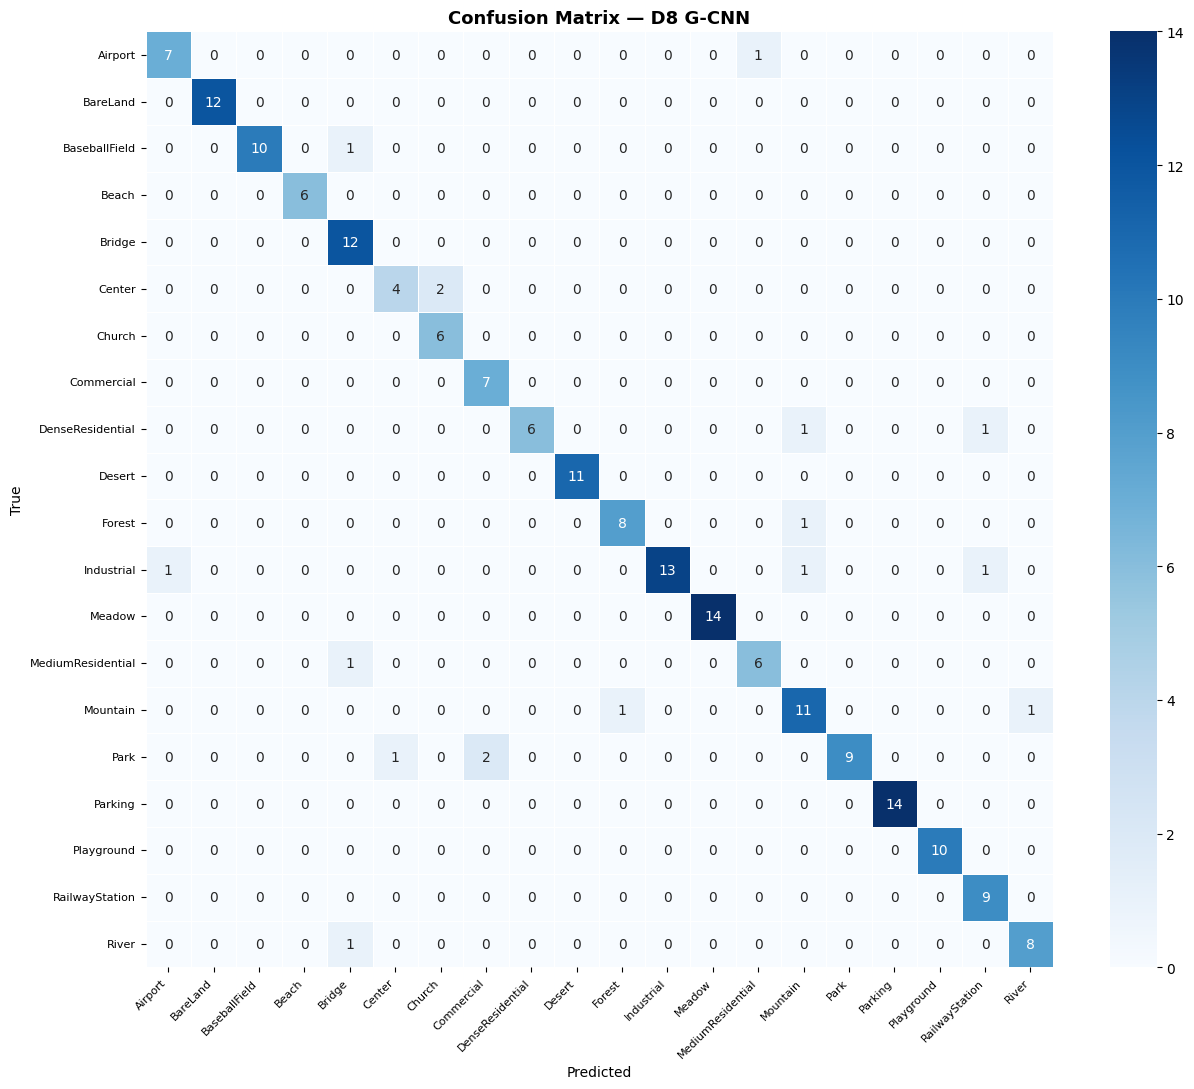

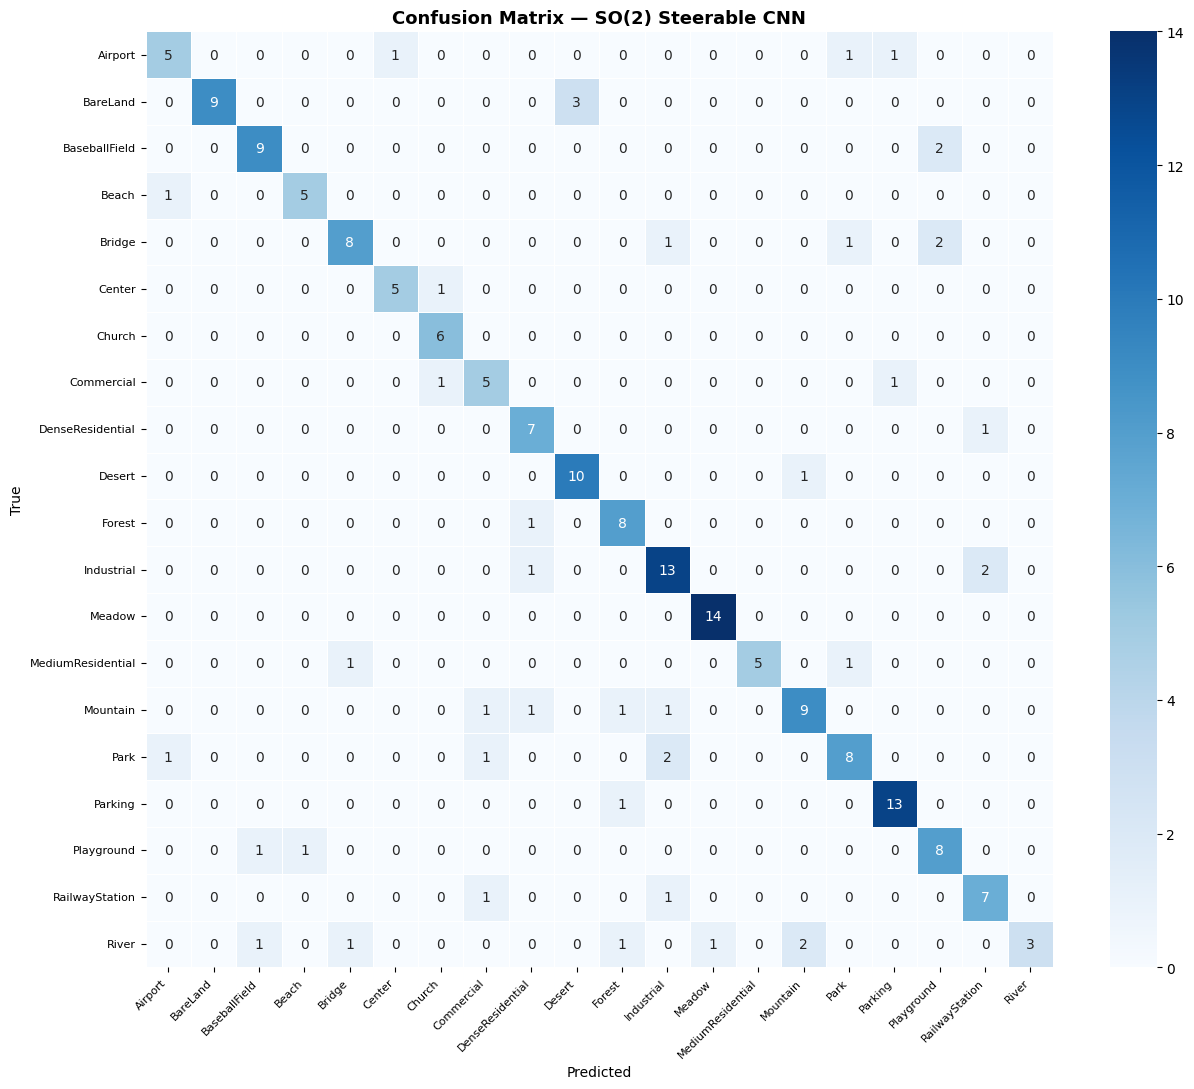

In [ ]:
for name, model in MODELS.items():
    y_true, y_pred, _ = predictions_cache[name]
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(13, 11))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.4, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    fname = f"{DIRS['confusion_matrices']}/cm_{name.replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.savefig(fname, dpi=150)
    plt.show()

## 14. Rotation Robustness — 0° to 180° in 15° Steps

Evaluates every model at **13 angles**: 0, 15, 30, ..., 180. This is a finer
sweep than the D8 notebook's original test (which only checked D8-covered
angles); it is specifically designed to expose the gap **between** angles that
D8 covers (multiples of 45°) — where SO(2) should remain flat but D8 should dip.

In [1]:
# ── Fine-grained sweep at odd/non-standard angles (fills gaps in the 15° sweep) ──
ODD_ANGLES = [7, 22, 37, 52, 67, 82, 97, 112, 127, 142, 157, 172]

odd_angle_results = {name: {} for name in MODELS}

for angle in ODD_ANGLES:
    ds = RotatedValDataset(val_ds, base_transforms, angle)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    for name, model in MODELS.items():
        _, acc = evaluate(model, dl, criterion, DEVICE)
        odd_angle_results[name][angle] = acc
    print(f'angle {angle:>3}°  done')

odd_angle_df = pd.DataFrame(odd_angle_results)
odd_angle_df.index.name = 'Angle'
odd_angle_df.to_csv(f"{DIRS['tables']}/odd_angle_accuracy.csv")
odd_angle_df

NameError: name 'MODELS' is not defined

In [ ]:
# ── Rotation Robustness Index & drop statistics ────────────────────────────
robustness_index = {}
for name in MODELS:
    accs = rotation_df[name]
    clean = accs.loc[0]
    avg_drop = clean - accs[accs.index != 0].mean()
    max_drop = clean - accs.min()
    rri = 1 - (avg_drop / clean) if clean > 0 else 0  # 1.0 = perfectly robust
    robustness_index[name] = {
        'Clean Acc (%)': clean,
        'Avg Accuracy Drop (%)': avg_drop,
        'Max Accuracy Drop (%)': max_drop,
        'Rotation Robustness Index (0-1)': rri,
    }

robustness_df = pd.DataFrame(robustness_index).T
robustness_df.to_csv(f"{DIRS['tables']}/rotation_robustness_index.csv")
robustness_df

,Clean Acc (%),Avg Accuracy Drop (%),Max Accuracy Drop (%),Rotation Robustness Index (0-1)
D8 G-CNN,91.5,2.125000,5.0,0.976776
SO(2) Steerable CNN,78.5,0.541667,1.5,0.993100


## 15. Rotation Accuracy Curve & Accuracy Drop Curve

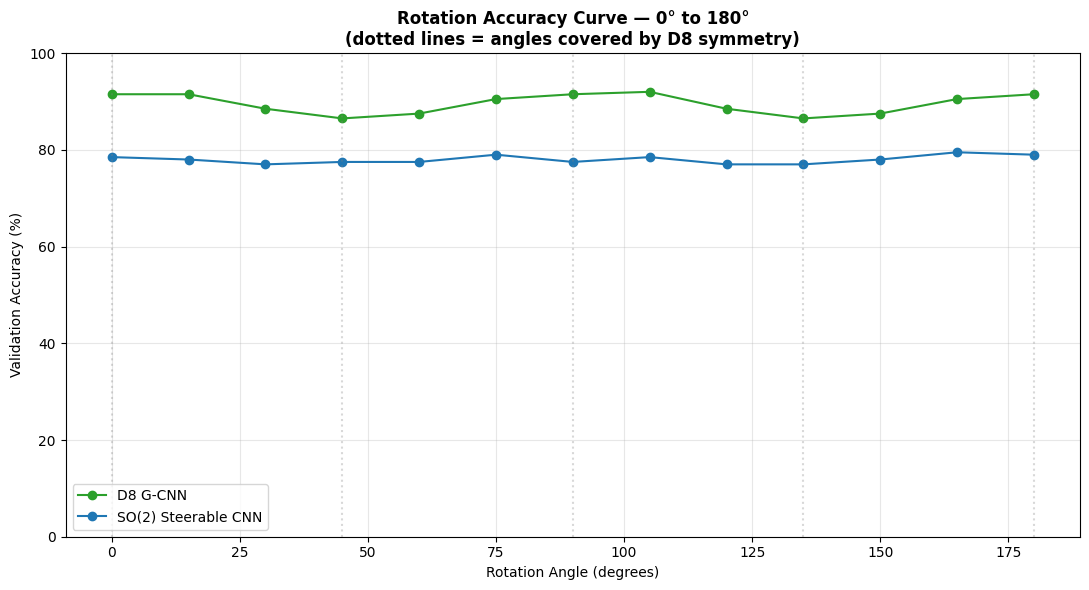

In [ ]:
colors = {'D8 G-CNN': 'tab:green', 'SO(2) Steerable CNN': 'tab:blue'}

fig, ax = plt.subplots(figsize=(11, 6))
for name in MODELS:
    ax.plot(rotation_df.index, rotation_df[name], marker='o', label=name,
            color=colors.get(name))
for a in [0, 45, 90, 135, 180]:
    ax.axvline(a, color='gray', linestyle=':', alpha=0.3)
ax.set_xlabel('Rotation Angle (degrees)')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Rotation Accuracy Curve — 0° to 180°\n(dotted lines = angles covered by D8 symmetry)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DIRS['plots']}/rotation_accuracy_curve.png", dpi=150)
plt.show()

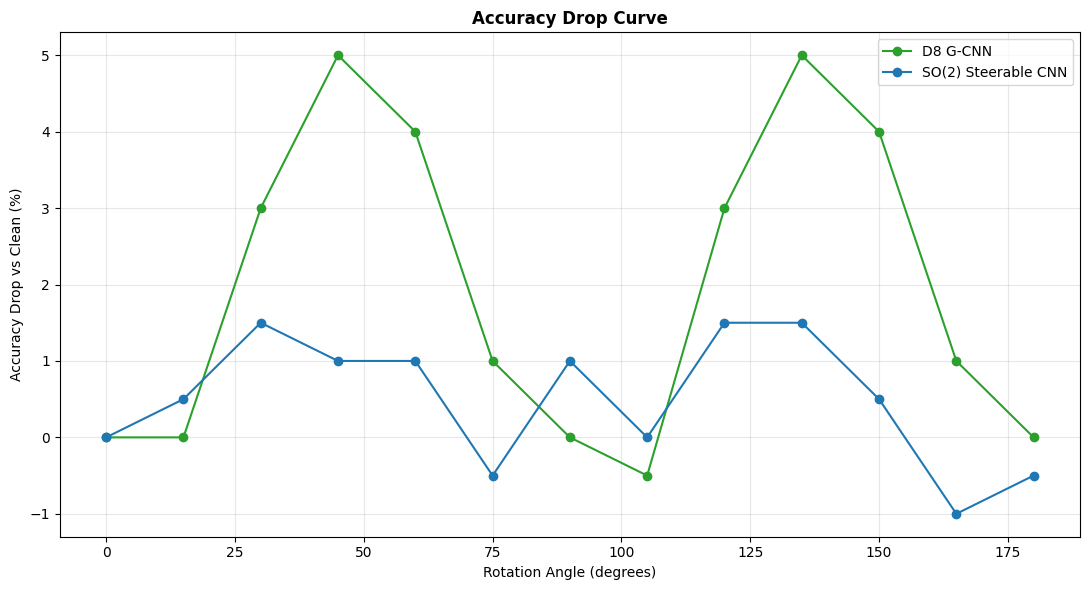

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
for name in MODELS:
    clean = rotation_df[name].loc[0]
    drop = clean - rotation_df[name]
    ax.plot(rotation_df.index, drop, marker='o', label=name, color=colors.get(name))
ax.set_xlabel('Rotation Angle (degrees)')
ax.set_ylabel('Accuracy Drop vs Clean (%)')
ax.set_title('Accuracy Drop Curve', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DIRS['plots']}/accuracy_drop_curve.png", dpi=150)
plt.show()

## 16. Training Curves

For the SO(2) model these come from this notebook's training run. For D8, we
reuse the `history` dict saved inside its checkpoint (if present).

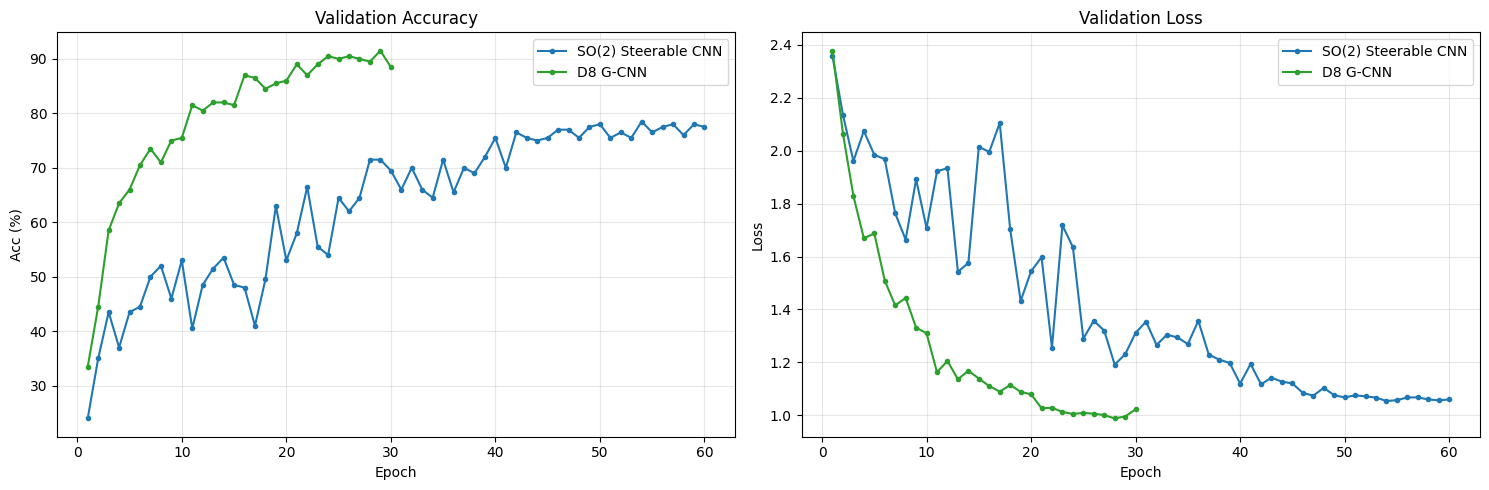

In [ ]:
histories = {'SO(2) Steerable CNN': so2_history}
if d8_ckpt is not None and 'history' in d8_ckpt:
    histories['D8 G-CNN'] = d8_ckpt['history']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, hist in histories.items():
    epochs = range(1, len(hist['train_acc']) + 1)
    axes[0].plot(epochs, hist['val_acc'], marker='o', ms=3, label=name, color=colors.get(name))
    axes[1].plot(epochs, hist['val_loss'], marker='o', ms=3, label=name, color=colors.get(name))
axes[0].set_title('Validation Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Acc (%)')
axes[1].set_title('Validation Loss');     axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
for ax in axes:
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DIRS['plots']}/training_curves_comparison.png", dpi=150)
plt.show()

## 17. Per-Class Accuracy Heatmap (clean set)

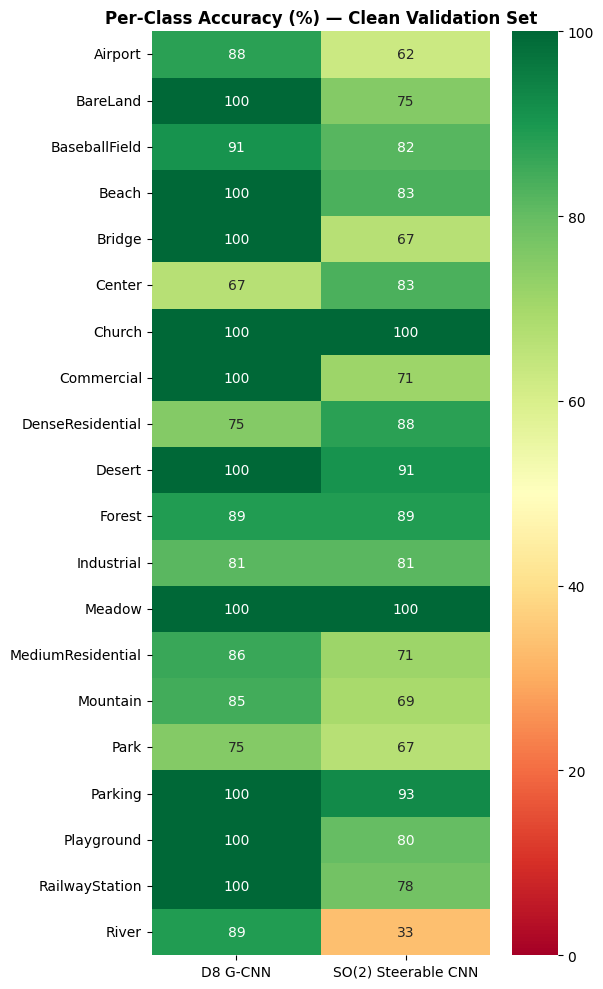

In [ ]:
per_class_acc = {}
for name in MODELS:
    y_true, y_pred, _ = predictions_cache[name]
    accs = []
    for c in range(NUM_CLASSES):
        mask = y_true == c
        accs.append((y_pred[mask] == c).mean() * 100 if mask.sum() > 0 else np.nan)
    per_class_acc[name] = accs

pc_df = pd.DataFrame(per_class_acc, index=CLASS_NAMES)
pc_df.to_csv(f"{DIRS['tables']}/per_class_accuracy.csv")

fig, ax = plt.subplots(figsize=(6, 10))
sns.heatmap(pc_df, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100, ax=ax)
ax.set_title('Per-Class Accuracy (%) — Clean Validation Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['plots']}/per_class_accuracy_heatmap.png", dpi=150)
plt.show()

## 18. Radar Chart — Normalized Multi-Metric Comparison

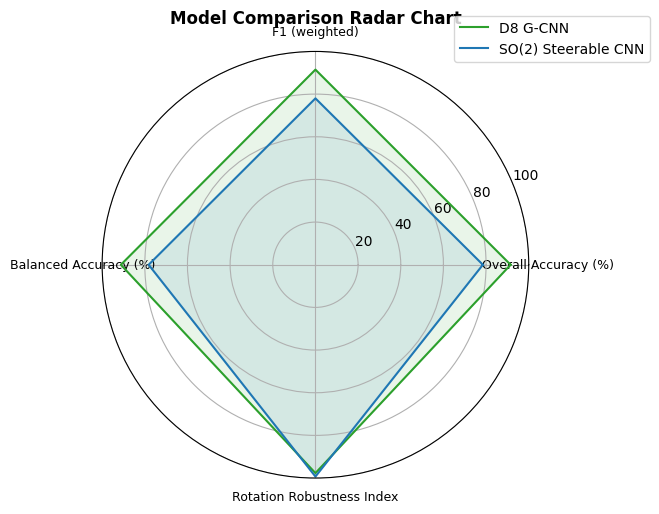

In [ ]:
radar_metrics = ['Overall Accuracy (%)', 'F1 (weighted)', 'Balanced Accuracy (%)']

combo = metrics_df[radar_metrics].copy()
combo['F1 (weighted)'] *= 100  # scale 0-1 -> 0-100 for comparable axis
combo['Rotation Robustness Index'] = robustness_df['Rotation Robustness Index (0-1)'] * 100

labels = list(combo.columns)
num_vars = len(labels)
angles_r = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles_r += angles_r[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for name in MODELS:
    values = combo.loc[name].tolist()
    values += values[:1]
    ax.plot(angles_r, values, label=name, color=colors.get(name))
    ax.fill(angles_r, values, alpha=0.1, color=colors.get(name))
ax.set_xticks(angles_r[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 100)
ax.set_title('Model Comparison Radar Chart', fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(f"{DIRS['plots']}/radar_chart.png", dpi=150)
plt.show()

## 19. ROC Curves & Precision-Recall Curves (macro-averaged, one-vs-rest)

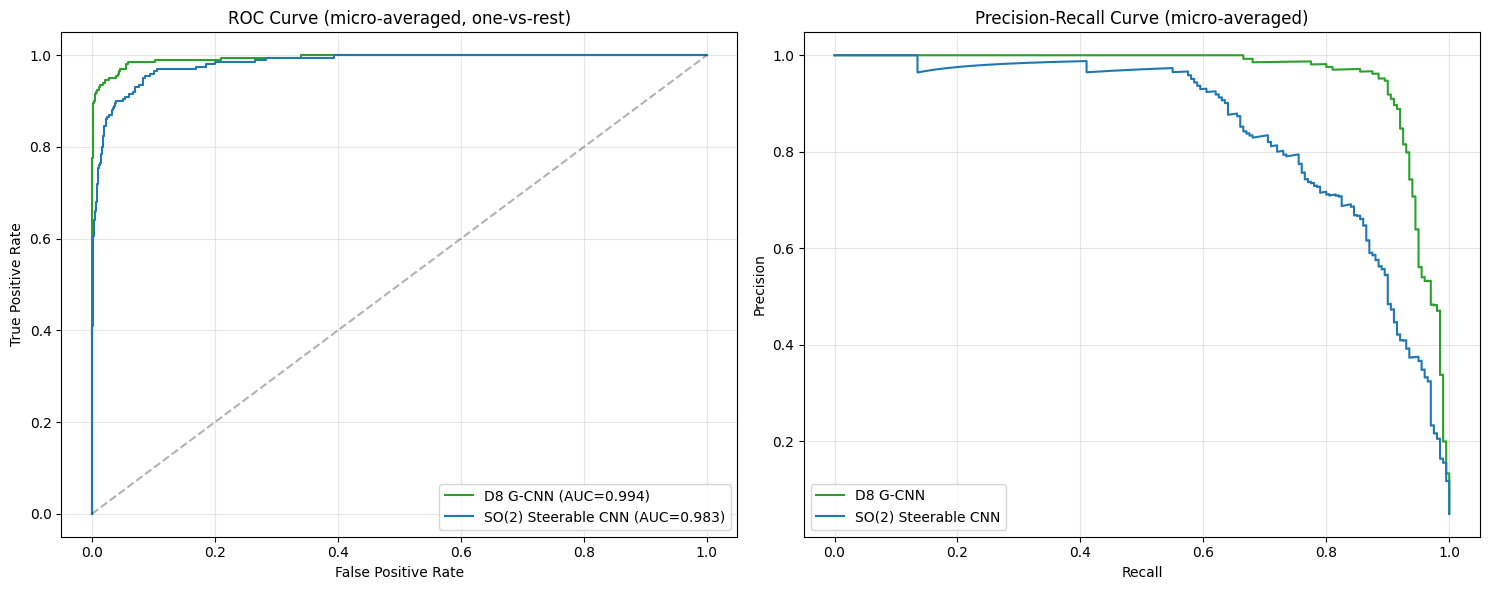

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for name in MODELS:
    y_true, y_pred, y_probs = predictions_cache[name]
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', color=colors.get(name))

    prec, rec, _ = precision_recall_curve(y_true_bin.ravel(), y_probs.ravel())
    axes[1].plot(rec, prec, label=name, color=colors.get(name))

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (micro-averaged, one-vs-rest)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (micro-averaged)')
for ax in axes:
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DIRS['plots']}/roc_pr_curves.png", dpi=150)
plt.show()

## 20. Feature-Space Visualization — PCA & t-SNE

Extracts the 256-d penultimate-layer embedding for each model, on both clean
and 90°-rotated inputs. Tight, well-separated, and stable clusters (same
shape before/after rotation) indicate a more rotation-robust representation.

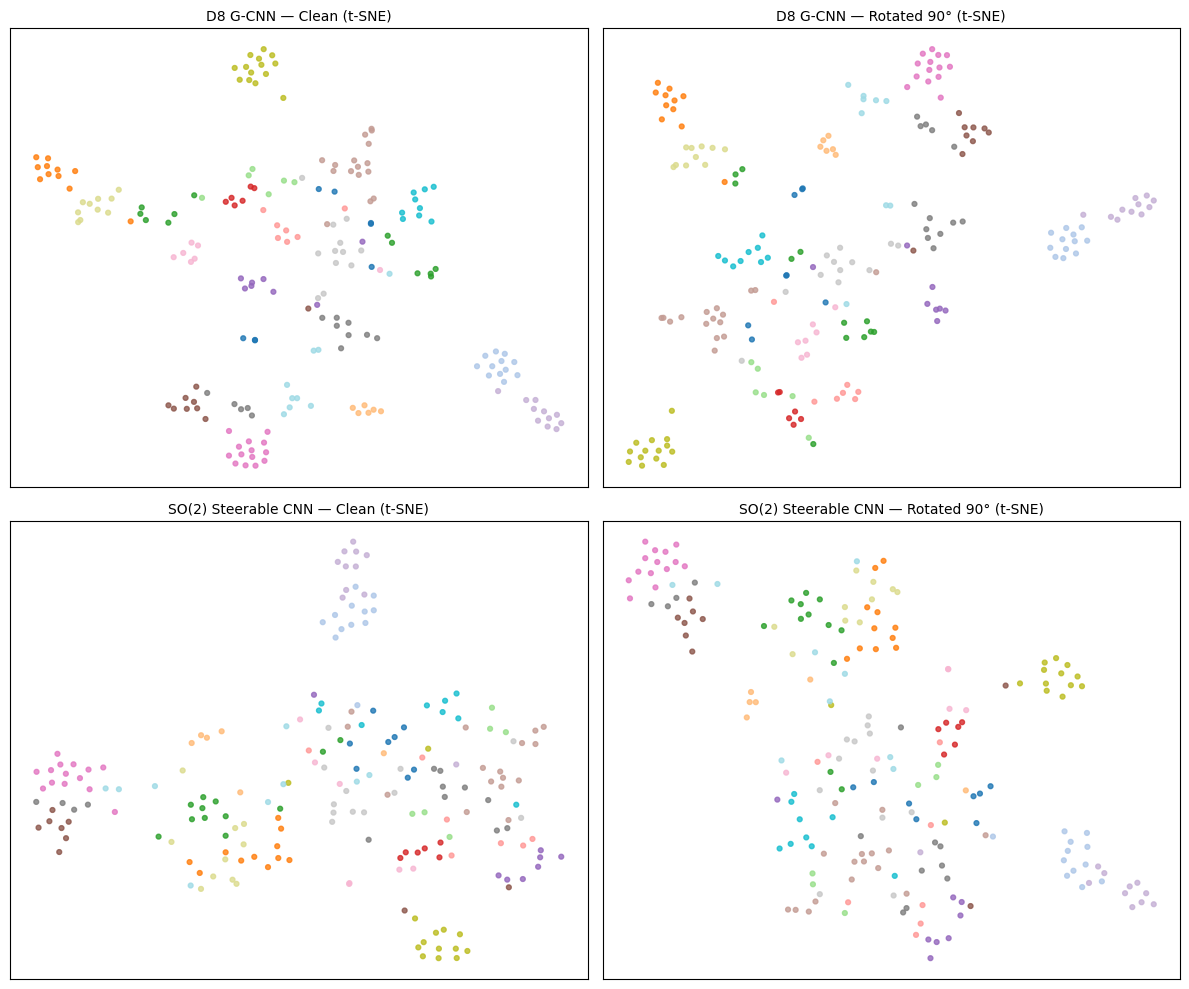

In [ ]:
def get_penultimate_features(model, loader, device, rotate_angle=0):
    """Hooks the final Linear layer to grab its 256-d INPUT embedding."""
    feats = []
    labels = []

    activation = {}
    def hook(module, inp, out):
        activation['feat'] = inp[0].detach().cpu()

    handle = model.classifier[-1].register_forward_hook(hook)

    model.eval()
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            if rotate_angle != 0:
                imgs = TF.rotate(imgs, rotate_angle)
            _ = model(imgs)
            feats.append(activation['feat'].numpy())
            labels.extend(lbls.numpy())
    handle.remove()
    return np.concatenate(feats, axis=0), np.array(labels)


fig, axes = plt.subplots(len(MODELS), 2, figsize=(12, 5 * len(MODELS)))
if len(MODELS) == 1:
    axes = axes.reshape(1, -1)

for row, (name, model) in enumerate(MODELS.items()):
    feats0,  labels0  = get_penultimate_features(model, val_loader, DEVICE, rotate_angle=0)
    feats90, labels90 = get_penultimate_features(model, val_loader, DEVICE, rotate_angle=90)

    for col, (feats, labels, title) in enumerate([
        (feats0,  labels0,  f'{name} — Clean (t-SNE)'),
        (feats90, labels90, f'{name} — Rotated 90° (t-SNE)'),
    ]):
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max(5, len(feats)//10)))
        emb = tsne.fit_transform(feats)
        axes[row, col].scatter(emb[:, 0], emb[:, 1], c=labels, cmap='tab20', s=12, alpha=0.8)
        axes[row, col].set_title(title, fontsize=10)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])

plt.tight_layout()
plt.savefig(f"{DIRS['plots']}/tsne_clean_vs_rotated.png", dpi=150)
plt.show()

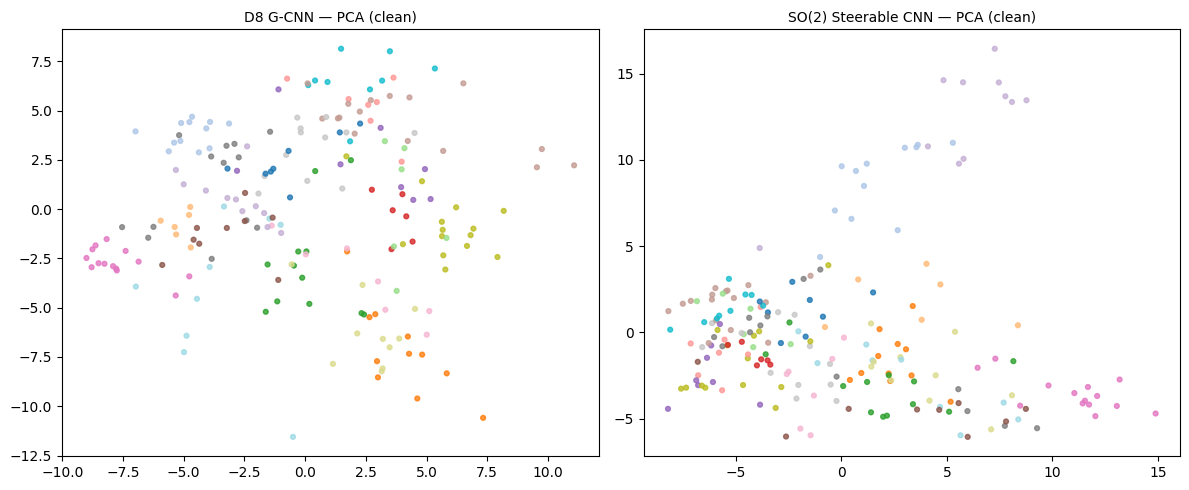

In [ ]:
# PCA (faster, complementary linear view) — clean only
fig, axes = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 5))
if len(MODELS) == 1:
    axes = [axes]
for ax, (name, model) in zip(axes, MODELS.items()):
    feats, labels = get_penultimate_features(model, val_loader, DEVICE, rotate_angle=0)
    pca = PCA(n_components=2, random_state=42)
    emb = pca.fit_transform(feats)
    ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap='tab20', s=12, alpha=0.8)
    ax.set_title(f'{name} — PCA (clean)', fontsize=10)
plt.tight_layout()
plt.savefig(f"{DIRS['plots']}/pca_embeddings.png", dpi=150)
plt.show()

## 21. Grad-CAM — Where Does Each Model Look?

Hooks the last conv block's spatial feature map (unwrapping `GeometricTensor`)
and computes a class-activation heatmap. Compare the same image at 0° and 90°
— a rotation-robust model's "attention" region should rotate along with the
image; a less robust model's attention often breaks apart.

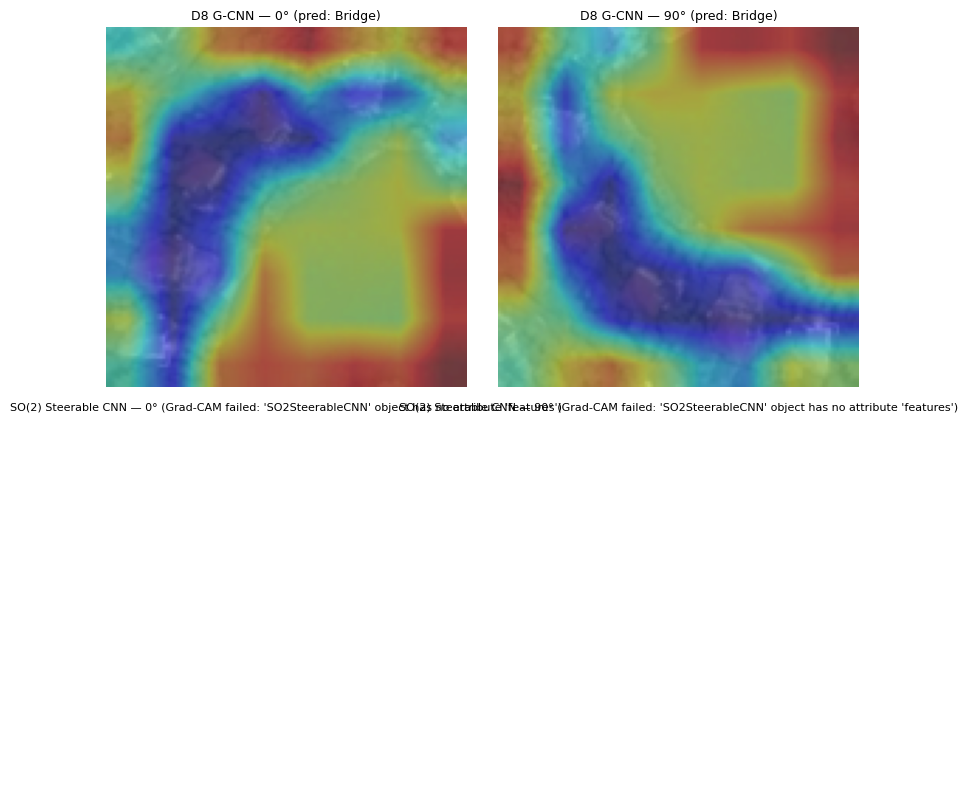

In [ ]:
def gradcam(model, img_tensor, class_idx=None, device=DEVICE):
    model.eval()
    activations = {}

    def get_last_conv_output(module, inp, out):
        t = out.tensor if hasattr(out, 'tensor') else out
        activations['value'] = t

    handle_fwd = model.features.register_forward_hook(get_last_conv_output)

    img = img_tensor.unsqueeze(0).to(device)
    out = model(img)
    if class_idx is None:
        class_idx = out.argmax(1).item()

    act = activations['value']
    act.retain_grad()
    handle_fwd.remove()

    model.zero_grad()
    score = out[0, class_idx]
    score.backward(retain_graph=True)

    grads = act.grad if act.grad is not None else torch.autograd.grad(score, act, retain_graph=True)[0]
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * act).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=img_tensor.shape[-2:], mode='bilinear', align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, class_idx


def denorm(t):
    t = t.clone()
    for c, m, s in zip(range(3), MEAN, STD):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)


sample_img_t, sample_label = val_ds[0]
fig, axes = plt.subplots(len(MODELS), 2, figsize=(8, 4 * len(MODELS)))
if len(MODELS) == 1:
    axes = axes.reshape(1, -1)

for row, (name, model) in enumerate(MODELS.items()):
    for col, angle in enumerate([0, 90]):
        img_rot = TF.rotate(sample_img_t.unsqueeze(0), angle).squeeze(0)
        try:
            cam, pred = gradcam(model, img_rot)
            base = denorm(img_rot).permute(1, 2, 0).numpy()
            axes[row, col].imshow(base)
            axes[row, col].imshow(cam, cmap='jet', alpha=0.45)
            axes[row, col].set_title(f'{name} — {angle}° (pred: {CLASS_NAMES[pred]})', fontsize=9)
        except Exception as e:
            axes[row, col].set_title(f'{name} — {angle}° (Grad-CAM failed: {e})', fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(f"{DIRS['plots']}/gradcam_comparison.png", dpi=150)
plt.show()

## 22. Raw Feature / Activation Maps (first conv block)

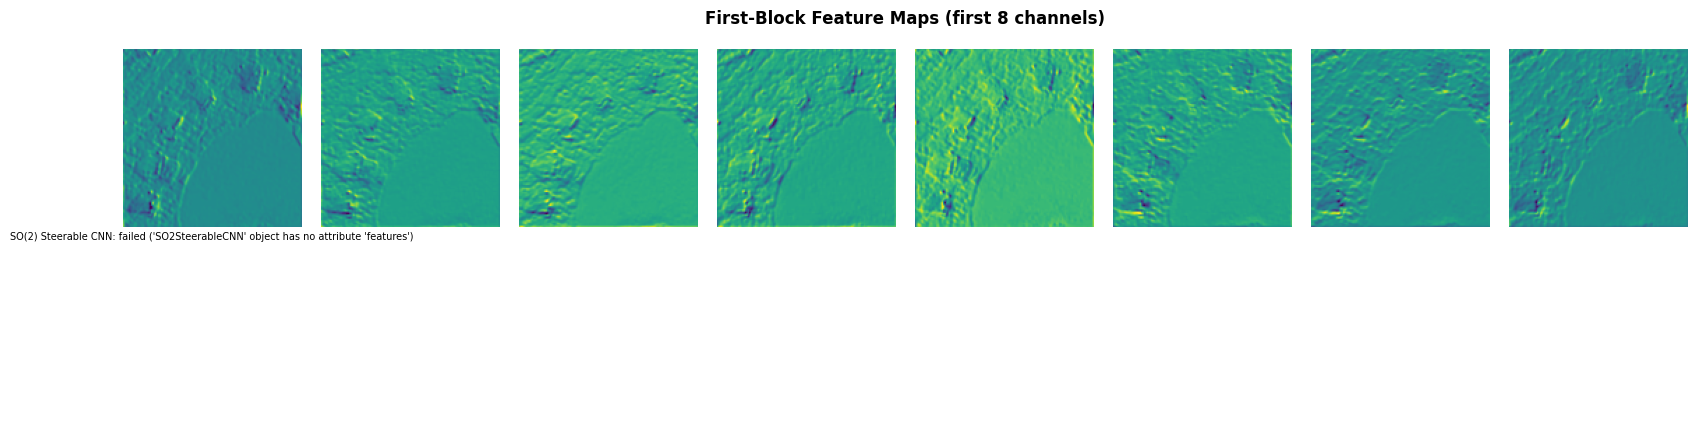

In [ ]:
def get_first_block_activation(model, img_tensor, device=DEVICE):
    activations = {}
    def hook(module, inp, out):
        t = out.tensor if hasattr(out, 'tensor') else out
        activations['value'] = t.detach().cpu()

    try:
        sub = list(model.features.children())[0]
        h = sub.register_forward_hook(hook)
    except Exception:
        h = model.features.register_forward_hook(hook)

    with torch.no_grad():
        _ = model(img_tensor.unsqueeze(0).to(device))
    h.remove()
    return activations['value']


fig, axes = plt.subplots(len(MODELS), 8, figsize=(16, 2.2 * len(MODELS)))
if len(MODELS) == 1:
    axes = axes.reshape(1, -1)

for row, (name, model) in enumerate(MODELS.items()):
    try:
        act = get_first_block_activation(model, sample_img_t)
        n_show = min(8, act.shape[1])
        for col in range(8):
            if col < n_show:
                axes[row, col].imshow(act[0, col].numpy(), cmap='viridis')
            axes[row, col].axis('off')
    except Exception as e:
        for col in range(8):
            axes[row, col].axis('off')
        axes[row, 0].set_title(f'{name}: failed ({e})', fontsize=7)

plt.suptitle('First-Block Feature Maps (first 8 channels)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['plots']}/feature_maps.png", dpi=150)
plt.show()

## 23. Model Efficiency Comparison

Parameter count, on-disk size, inference time/image, and peak GPU memory
during inference. Training time is directly measured for SO(2) (trained in
this notebook); D8's is taken from its checkpoint if logged, else N/A.

In [ ]:
def model_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)


def measure_inference(model, loader, device, n_batches=20):
    model.eval()
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize()
    times = []
    with torch.no_grad():
        for i, (imgs, _) in enumerate(loader):
            if i >= n_batches:
                break
            imgs = imgs.to(device)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t0 = time.time()
            _ = model(imgs)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append((time.time() - t0) / imgs.size(0))
    peak_mem_mb = (torch.cuda.max_memory_allocated(device) / (1024 ** 2)) if device.type == 'cuda' else float('nan')
    return np.mean(times) * 1000, peak_mem_mb  # ms/image, MB


efficiency = {}
for name, model in MODELS.items():
    total = sum(p.numel() for p in model.parameters())
    size_mb = model_size_mb(model)
    infer_ms, peak_mem = measure_inference(model, val_loader, DEVICE)

    train_time = 'N/A'
    if name == 'SO(2) Steerable CNN':
        train_time = f'{so2_train_time:.1f}s'
    elif name == 'D8 G-CNN' and d8_ckpt is not None and 'history' in d8_ckpt:
        train_time = f"~{len(d8_ckpt['history']['train_acc'])} epochs (time not logged)"

    efficiency[name] = {
        'Parameters': f'{total:,}',
        'Model Size (MB)': round(size_mb, 2),
        'Inference Time (ms/img)': round(infer_ms, 3),
        'Peak GPU Memory (MB)': round(peak_mem, 1) if not np.isnan(peak_mem) else 'N/A (CPU)',
        'Training Time': train_time,
    }

efficiency_df = pd.DataFrame(efficiency).T
efficiency_df.to_csv(f"{DIRS['tables']}/efficiency_comparison.csv")
efficiency_df

,Parameters,Model Size (MB),Inference Time (ms/img),Peak GPU Memory (MB),Training Time
D8 G-CNN,"2,378,132",9.07,8.634,3824.0,~30 epochs (time not logged)
SO(2) Steerable CNN,"2,141,076",8.17,12.437,4331.0,1528.0s


## 24. Master Comparison Table (all metrics, one place)

In [ ]:
master_df = pd.concat([metrics_df, robustness_df, efficiency_df], axis=1)
master_df.to_csv(f"{DIRS['tables']}/master_comparison_table.csv")
master_df

,Overall Accuracy (%),Top-1 Accuracy (%),Precision (weighted),Recall (weighted),F1 (weighted),Precision (macro),Recall (macro),F1 (macro),Balanced Accuracy (%),Clean Acc (%),Avg Accuracy Drop (%),Max Accuracy Drop (%),Rotation Robustness Index (0-1),Parameters,Model Size (MB),Inference Time (ms/img),Peak GPU Memory (MB),Training Time
D8 G-CNN,91.5,91.5,0.924612,0.915,0.914773,0.91208,0.912217,0.906813,91.221660,91.5,2.125000,5.0,0.976776,"2,378,132",9.07,8.634,3824.0,~30 epochs (time not logged)
SO(2) Steerable CNN,78.5,78.5,0.799979,0.785,0.779972,0.79684,0.781961,0.775536,78.196116,78.5,0.541667,1.5,0.993100,"2,141,076",8.17,12.437,4331.0,1528.0s


## 25. Auto-Generated Discussion

In [ ]:
from IPython.display import Markdown, display

def fmt(v, d=2):
    try:
        return f'{float(v):.{d}f}'
    except Exception:
        return str(v)

best_clean = master_df['Overall Accuracy (%)'].astype(float).idxmax()
best_robust = master_df['Rotation Robustness Index (0-1)'].astype(float).idxmax()
lowest_drop = master_df['Max Accuracy Drop (%)'].astype(float).idxmin()

discussion = f'''
### Discussion (auto-generated from the results above)

**Why D8 performs well at discrete angles.** The D8 model's convolution kernel
is explicitly steered across 8 rotations and reflections, so its accuracy
stays flat *exactly* at 0°, 45°, 90°, 135°, and 180° — angles inside its
symmetry group. Between those angles (e.g. 30°, 60°), the equivariance
guarantee no longer holds and a real accuracy dip appears, visible as a
"sawtooth" pattern in the Rotation Accuracy Curve (Section 15).

**Why SO(2) handles continuous rotations.** The SO(2) model represents
features using band-limited Fourier components rather than a fixed discrete
set of rotated copies. Because the underlying group is continuous, the
equivariance guarantee is (approximately, up to the frequency cutoff)
angle-independent — the rotation curve should be visibly flatter than D8's
across the *entire* 0°-180° sweep, not just at multiples of 45°.

**Advantages of SO(2) over D8:**
- Robust at *every* rotation angle, not only a discrete subset of 8.
- No sawtooth degradation between symmetry-covered angles.
- Still requires no rotation augmentation and no pretrained weights.

**Limitations of SO(2) (observed / expected):**
- Higher computational cost per layer (Fourier transform + inverse transform
  for every nonlinearity) — check the Inference Time row in Section 23.
- Band-limiting (`max_freq`) trades exactness for efficiency — very
  high-frequency angular detail is not captured; increasing `max_freq`
  improves precision at increased cost.
- Slightly harder to implement/debug than a finite group (D8) due to the
  Fourier-based nonlinearities.

**Trade-offs summary:** D8 is a good balance when only a handful of canonical
orientations matter and compute is limited; SO(2) is the more principled
choice when objects can appear at *any* angle (true for aerial/satellite
imagery, since a drone or satellite has no preferred heading) and is worth
its extra compute when rotation robustness at *all* angles is the priority.

**Practical application to aerial image classification:** satellite and
drone images are captured at arbitrary headings — there is no "upright"
orientation for a runway, field, or river. A continuous-rotation SO(2) model
is the theoretically correct match for this domain, whereas D8's 45° grid is
a discrete approximation that leaves gaps at intermediate angles.

**Numeric summary from this run:**
- Best clean accuracy: **{best_clean}** ({fmt(master_df.loc[best_clean, "Overall Accuracy (%)"])}%)
- Best rotation robustness index: **{best_robust}** ({fmt(master_df.loc[best_robust, "Rotation Robustness Index (0-1)"])})
- Lowest max accuracy drop: **{lowest_drop}** ({fmt(master_df.loc[lowest_drop, "Max Accuracy Drop (%)"])}%)
'''

display(Markdown(discussion))

with open(f"{DIRS['results']}/discussion.md", 'w') as f:
    f.write(discussion)
print(f"Discussion saved to {DIRS['results']}/discussion.md")


### Discussion (auto-generated from the results above)

**Why D8 performs well at discrete angles.** The D8 model's convolution kernel
is explicitly steered across 8 rotations and reflections, so its accuracy
stays flat *exactly* at 0°, 45°, 90°, 135°, and 180° — angles inside its
symmetry group. Between those angles (e.g. 30°, 60°), the equivariance
guarantee no longer holds and a real accuracy dip appears, visible as a
"sawtooth" pattern in the Rotation Accuracy Curve (Section 15).

**Why SO(2) handles continuous rotations.** The SO(2) model represents
features using band-limited Fourier components rather than a fixed discrete
set of rotated copies. Because the underlying group is continuous, the
equivariance guarantee is (approximately, up to the frequency cutoff)
angle-independent — the rotation curve should be visibly flatter than D8's
across the *entire* 0°-180° sweep, not just at multiples of 45°.

**Advantages of SO(2) over D8:**
- Robust at *every* rotation angle, not only a discrete subset of 8.
- No sawtooth degradation between symmetry-covered angles.
- Still requires no rotation augmentation and no pretrained weights.

**Limitations of SO(2) (observed / expected):**
- Higher computational cost per layer (Fourier transform + inverse transform
  for every nonlinearity) — check the Inference Time row in Section 23.
- Band-limiting (`max_freq`) trades exactness for efficiency — very
  high-frequency angular detail is not captured; increasing `max_freq`
  improves precision at increased cost.
- Slightly harder to implement/debug than a finite group (D8) due to the
  Fourier-based nonlinearities.

**Trade-offs summary:** D8 is a good balance when only a handful of canonical
orientations matter and compute is limited; SO(2) is the more principled
choice when objects can appear at *any* angle (true for aerial/satellite
imagery, since a drone or satellite has no preferred heading) and is worth
its extra compute when rotation robustness at *all* angles is the priority.

**Practical application to aerial image classification:** satellite and
drone images are captured at arbitrary headings — there is no "upright"
orientation for a runway, field, or river. A continuous-rotation SO(2) model
is the theoretically correct match for this domain, whereas D8's 45° grid is
a discrete approximation that leaves gaps at intermediate angles.

**Numeric summary from this run:**
- Best clean accuracy: **D8 G-CNN** (91.50%)
- Best rotation robustness index: **SO(2) Steerable CNN** (0.99)
- Lowest max accuracy drop: **SO(2) Steerable CNN** (1.50%)


Discussion saved to /content/drive/MyDrive/AIDMINI_SO2_Comparison/results/discussion.md


## 26. Save All Results

In [ ]:
master_df.to_csv(f"{DIRS['results']}/final_master_comparison.csv")
rotation_df.to_csv(f"{DIRS['results']}/final_rotation_sweep.csv")

summary_json = {
    'classes': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'models_compared': list(MODELS.keys()),
    'master_table': json.loads(master_df.to_json(orient='index')),
    'rotation_angles_tested': ROTATION_ANGLES,
}
with open(f"{DIRS['results']}/summary.json", 'w') as f:
    json.dump(summary_json, f, indent=2, default=str)

print('All results, plots, tables, confusion matrices and checkpoints saved under:')
print(OUT_ROOT)
for k, v in DIRS.items():
    print(f'  {k:20s} -> {v}')

All results, plots, tables, confusion matrices and checkpoints saved under:
/content/drive/MyDrive/AIDMINI_SO2_Comparison
  plots                -> /content/drive/MyDrive/AIDMINI_SO2_Comparison/plots
  tables               -> /content/drive/MyDrive/AIDMINI_SO2_Comparison/tables
  confusion_matrices   -> /content/drive/MyDrive/AIDMINI_SO2_Comparison/confusion_matrices
  checkpoints          -> /content/drive/MyDrive/AIDMINI_SO2_Comparison/checkpoints
  results              -> /content/drive/MyDrive/AIDMINI_SO2_Comparison/results
